<a href="https://colab.research.google.com/github/NyasaShaiju/Task6-K-Nearest_Neighbors_-KNN-_Classification/blob/main/Task6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task6-K-Nearest Neighbors (KNN) Classification

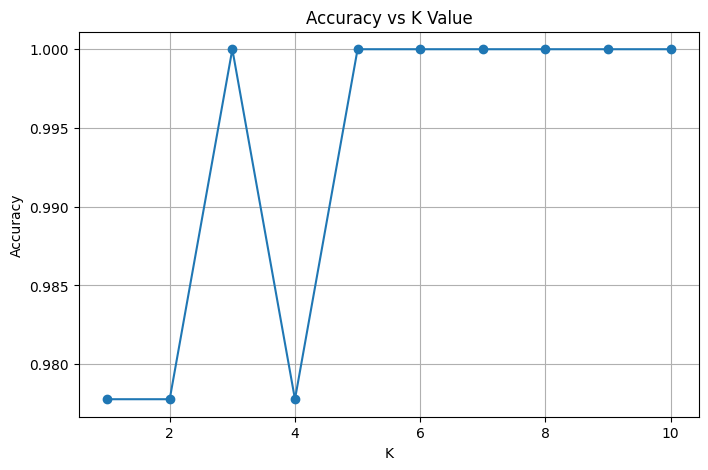

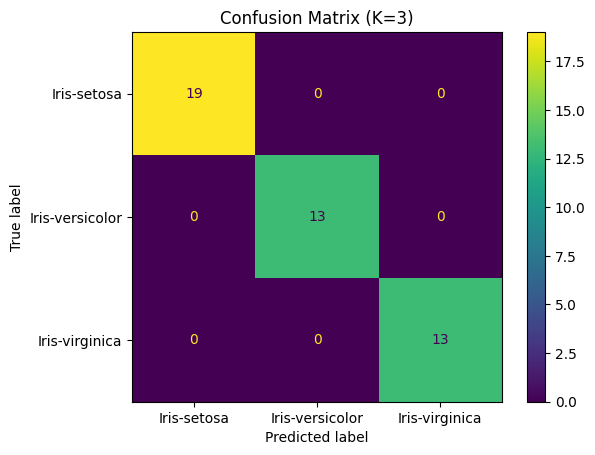

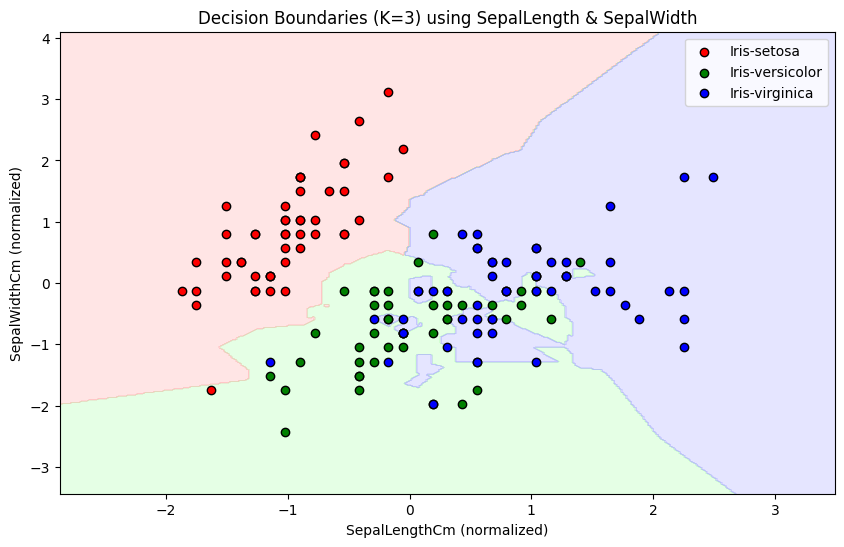

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay


df = pd.read_csv("/content/Iris.csv")

X = df.drop(columns=["Id", "Species"])
y = df["Species"]


scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)

k_values = range(1, 11)
accuracies = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    accuracies.append(acc)

plt.figure(figsize=(8, 5))
plt.plot(k_values, accuracies, marker='o')
plt.title("Accuracy vs K Value")
plt.xlabel("K")
plt.ylabel("Accuracy")
plt.grid(True)
plt.show()

best_k = k_values[np.argmax(accuracies)]
final_knn = KNeighborsClassifier(n_neighbors=best_k)
final_knn.fit(X_train, y_train)
final_preds = final_knn.predict(X_test)

cm = confusion_matrix(y_test, final_preds, labels=final_knn.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=final_knn.classes_)
disp.plot()
plt.title(f"Confusion Matrix (K={best_k})")
plt.show()

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

X_vis = X_scaled[:, :2]
X_train_vis, X_test_vis, y_train_vis, y_test_vis = train_test_split(X_vis, y_encoded, test_size=0.3, random_state=42)

knn_vis = KNeighborsClassifier(n_neighbors=best_k)
knn_vis.fit(X_train_vis, y_train_vis)

x_min, x_max = X_vis[:, 0].min() - 1, X_vis[:, 0].max() + 1
y_min, y_max = X_vis[:, 1].min() - 1, X_vis[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

Z = knn_vis.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(10, 6))
cmap_light = ListedColormap(['#FFAAAA', '#AAFFAA', '#AAAAFF'])
cmap_bold = ['red', 'green', 'blue']

plt.contourf(xx, yy, Z, alpha=0.3, cmap=cmap_light)
for idx, class_value in enumerate(np.unique(y_encoded)):
    plt.scatter(X_vis[y_encoded == class_value, 0], X_vis[y_encoded == class_value, 1],
                label=label_encoder.inverse_transform([class_value])[0], edgecolor='k', color=cmap_bold[idx])

plt.xlabel("SepalLengthCm (normalized)")
plt.ylabel("SepalWidthCm (normalized)")
plt.title(f"Decision Boundaries (K={best_k}) using SepalLength & SepalWidth")
plt.legend()
plt.show()
